In [ ]:
import torch
import pandas as pd
from transformers import AutoTokenizer, trainer, training_args

In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "katarinagresova/Genomic_Benchmarks_human_nontata_promoters"
)

dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/472 [00:00<?, ?B/s]

data/train-00000-of-00001-aeb55728756a44(…):   0%|          | 0.00/3.31M [00:00<?, ?B/s]

data/test-00000-of-00001-d7614d9116c62f4(…):   0%|          | 0.00/1.11M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/27097 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/9034 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['seq', 'label'],
        num_rows: 27097
    })
    test: Dataset({
        features: ['seq', 'label'],
        num_rows: 9034
    })
})

In [ ]:
print(dataset["train"][0])

{'seq': 'CAAGGGTGTAGTGCCCTGAGGGTGGCAATAGTTCCTGAGGCCATAACTGTTCTGAGCCCTTGCTGGGTGCCAGGCACAGTGCTGCTAGTGCGCTCTGCAGAGCTGATCTCACAATAACTTTTGGAGGTGCAAATACTCTATCCAGTTTATGAATGAGGAAACTGAGGCACAAAGTGGCTCCATGACTTGCCTGAGTCCCCACAGCTAGTAAGGGATGCCAGCAGGCGTTGAACCTCAACCCTAGAGCCTGC', 'label': 0}


In [ ]:
dataset["train"].column_names

['seq', 'label']

In [ ]:
def generate_kmers(sequence, k=6):
    return " ".join(
        [sequence[i:i+k] for i in range(len(sequence)-k+1)]
    )

In [ ]:
generate_kmers("ATGCGATCG")

'ATGCGA TGCGAT GCGATC CGATCG'

In [ ]:
def preprocess(example):
    example["text"] = generate_kmers(example["seq"])
    return example

dataset = dataset.map(preprocess)

Map:   0%|          | 0/27097 [00:00<?, ? examples/s]

Map:   0%|          | 0/9034 [00:00<?, ? examples/s]

In [ ]:
dataset["train"][0]["text"]

'CAAGGG AAGGGT AGGGTG GGGTGT GGTGTA GTGTAG TGTAGT GTAGTG TAGTGC AGTGCC GTGCCC TGCCCT GCCCTG CCCTGA CCTGAG CTGAGG TGAGGG GAGGGT AGGGTG GGGTGG GGTGGC GTGGCA TGGCAA GGCAAT GCAATA CAATAG AATAGT ATAGTT TAGTTC AGTTCC GTTCCT TTCCTG TCCTGA CCTGAG CTGAGG TGAGGC GAGGCC AGGCCA GGCCAT GCCATA CCATAA CATAAC ATAACT TAACTG AACTGT ACTGTT CTGTTC TGTTCT GTTCTG TTCTGA TCTGAG CTGAGC TGAGCC GAGCCC AGCCCT GCCCTT CCCTTG CCTTGC CTTGCT TTGCTG TGCTGG GCTGGG CTGGGT TGGGTG GGGTGC GGTGCC GTGCCA TGCCAG GCCAGG CCAGGC CAGGCA AGGCAC GGCACA GCACAG CACAGT ACAGTG CAGTGC AGTGCT GTGCTG TGCTGC GCTGCT CTGCTA TGCTAG GCTAGT CTAGTG TAGTGC AGTGCG GTGCGC TGCGCT GCGCTC CGCTCT GCTCTG CTCTGC TCTGCA CTGCAG TGCAGA GCAGAG CAGAGC AGAGCT GAGCTG AGCTGA GCTGAT CTGATC TGATCT GATCTC ATCTCA TCTCAC CTCACA TCACAA CACAAT ACAATA CAATAA AATAAC ATAACT TAACTT AACTTT ACTTTT CTTTTG TTTTGG TTTGGA TTGGAG TGGAGG GGAGGT GAGGTG AGGTGC GGTGCA GTGCAA TGCAAA GCAAAT CAAATA AAATAC AATACT ATACTC TACTCT ACTCTA CTCTAT TCTATC CTATCC TATCCA ATCCAG TCCAGT CCAGTT CAGTT

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "zhihan1996/DNA_bert_6"
)

config.json:   0%|          | 0.00/1.45k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/40.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/28.7k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/27097 [00:00<?, ? examples/s]

Map:   0%|          | 0/9034 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "zhihan1996/DNA_bert_6",
    num_labels=2
)

pytorch_model.bin:   0%|          | 0.00/359M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/359M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: zhihan1996/DNA_bert_6
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy.compute(
        predictions=predictions,
        references=labels
    )

    f1_score = f1.compute(
        predictions=predictions,
        references=labels
    )

    return {
        "accuracy": acc["accuracy"],
        "f1": f1_score["f1"]
    }

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./dnabert_results",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=5,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=2,

    fp16=True,

    report_to="none"
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=tokenized_dataset["train"],

    eval_dataset=tokenized_dataset["test"],

    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


In [ ]:
trainer.evaluate()
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import numpy as np

predictions = trainer.predict(tokenized_dataset["test"])

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print(classification_report(y_true, y_pred))

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.133339,0.341636,5,0.862409,0.876158


              precision    recall  f1-score   support

           0       0.87      0.82      0.85      4119
           1       0.86      0.89      0.88      4915

    accuracy                           0.86      9034
   macro avg       0.86      0.86      0.86      9034
weighted avg       0.86      0.86      0.86      9034



In [ ]:
trainer.save_model("DNABERT-Promoter-Classifier")
tokenizer.save_pretrained("DNABERT-Promoter-Classifier")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('DNABERT-Promoter-Classifier/tokenizer_config.json',
 'DNABERT-Promoter-Classifier/tokenizer.json')

In [ ]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained("./dnabert_results/checkpoint-16940")
print(config)

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForSequenceClassification"
  ],
  "attention_probs_dropout_prob": 0.1,
  "auto_map": {
    "AutoConfig": "configuration_bert.BertConfig",
    "AutoModel": "dnabert_layer.BertModel",
    "AutoModelForMaskedLM": "dnabert_layer.BertForMaskedLM",
    "AutoModelForPreTraining": "dnabert_layer.BertForPreTraining",
    "AutoModelForSequenceClassification": "dnabert_layer.DNABertForSequenceClassification"
  },
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "eos_token_ids": 0,
  "finetuning_task": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "num_rnn_layer": 1,
  "output_past": true,
  "pad_token_id": 0,
  "proble

In [ ]:
import os

print(os.listdir("./dnabert_results/checkpoint-16940"))

['scaler.pt', 'optimizer.pt', 'scheduler.pt', 'trainer_state.json', 'config.json', 'training_args.bin', 'rng_state.pth', 'model.safetensors']


In [ ]:
from transformers import AutoModelForSequenceClassification
from transformers import Trainer

model = AutoModelForSequenceClassification.from_pretrained(
    "./dnabert_results/checkpoint-16940"
)

trainer = Trainer(model=model)

predictions = trainer.predict(tokenized_dataset["test"])

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91      4119
           1       0.98      0.85      0.91      4915

    accuracy                           0.91      9034
   macro avg       0.91      0.91      0.91      9034
weighted avg       0.92      0.91      0.91      9034



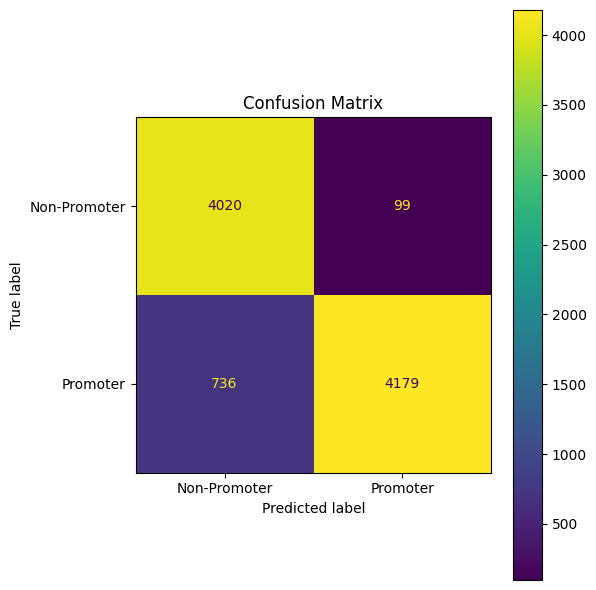

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Promoter", "Promoter"]
)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, values_format="d")

plt.title("Confusion Matrix")
plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300)

plt.show()

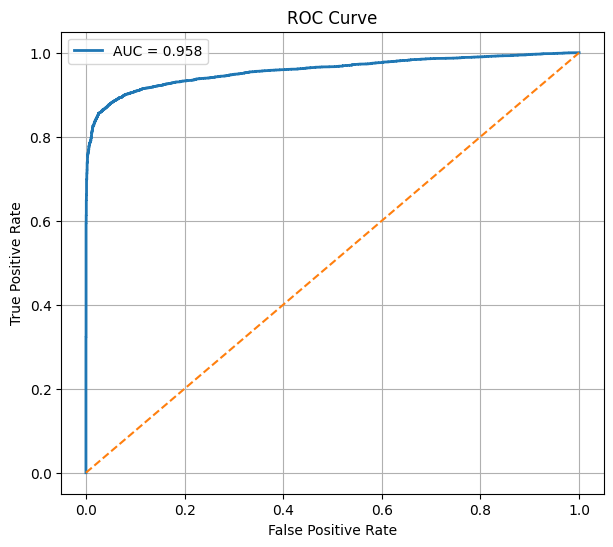

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability of promoter class
y_score = predictions.predictions[:,1]

fpr, tpr, _ = roc_curve(y_true, y_score)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr,
         linewidth=2,
         label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.savefig("roc_curve.png", dpi=300)

plt.show()

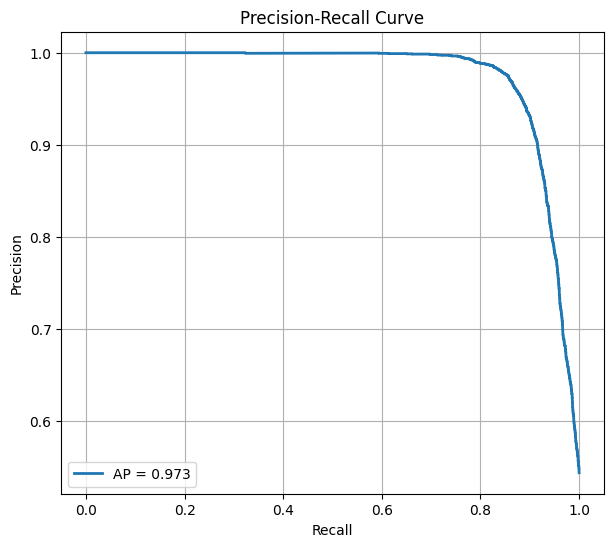

In [ ]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

precision, recall, _ = precision_recall_curve(
    y_true,
    y_score
)

ap = average_precision_score(y_true, y_score)

plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"AP = {ap:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.grid(True)

plt.savefig("precision_recall_curve.png", dpi=300)

plt.show()

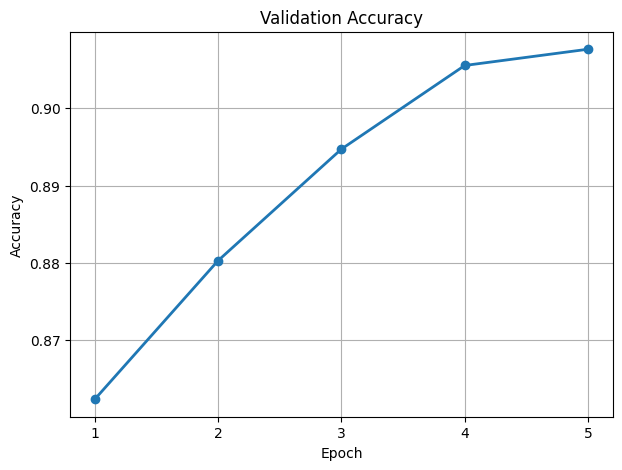

In [ ]:
epochs = [1,2,3,4,5]

accuracy = [
    0.8624,
    0.8803,
    0.8947,
    0.9055,
    0.9076
]

plt.figure(figsize=(7,5))

plt.plot(
    epochs,
    accuracy,
    marker="o",
    linewidth=2
)

plt.xticks(epochs)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Validation Accuracy")

plt.grid(True)

plt.savefig("accuracy_curve.png", dpi=300)

plt.show()

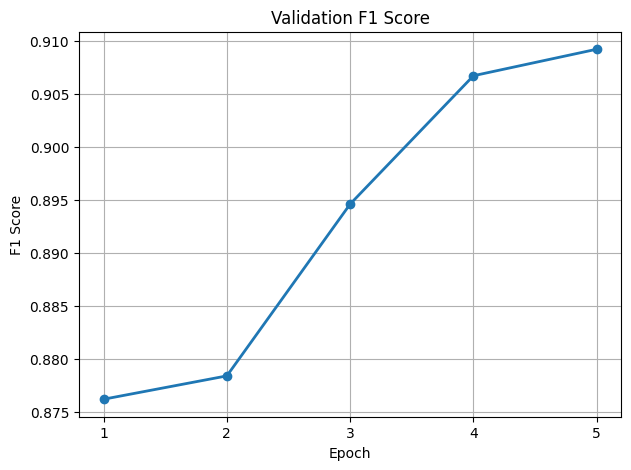

In [ ]:
epochs = [1,2,3,4,5]

f1 = [
    0.8762,
    0.8784,
    0.8946,
    0.9067,
    0.9092
]

plt.figure(figsize=(7,5))

plt.plot(
    epochs,
    f1,
    marker="o",
    linewidth=2
)

plt.xticks(epochs)

plt.xlabel("Epoch")

plt.ylabel("F1 Score")

plt.title("Validation F1 Score")

plt.grid(True)

plt.savefig("f1_curve.png", dpi=300)

plt.show()